### Finding Cluster

In [1]:
import pandas as pd
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt

C:\Users\chris\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\chris\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
C:\Users\chris\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
folder_path = "Stocks"

dfs=[]
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df = df.pivot_table(index=[], columns='Date', values=file[:-4])
        dfs.append(df)

df=pd.concat(dfs)
df_price=df.copy()
df=df.pct_change(axis=1)
df=df.drop(['2023-01-03'],axis=1)



In [3]:
#Apply PCA
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(df)
pca = PCA(n_components=15) # Adjust the number of components as needed
pca_data = pca.fit_transform(returns_scaled)

In [4]:
optics = OPTICS(min_samples=2)  # Adjust parameters as needed
clusters = optics.fit_predict(pca_data)  # Fit OPTICS on PCA data
pca_df = pd.DataFrame(data=pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
pca_df['Cluster'] = clusters  # Add cluster label to DataFrame
pca_df.index=df.index

In [5]:
clusters={}
for i, row in pca_df.iterrows():
    if row['Cluster'] not in clusters:
        clusters[row['Cluster']]=[i]
    else:
        clusters[row['Cluster']].append(i)

clusters

{-1.0: ['AAPL',
  'AMGN',
  'AMZN',
  'BA',
  'CAT',
  'CRM',
  'CVX',
  'DIS',
  'MMM',
  'MRK',
  'MSFT',
  'NKE',
  'NVDA',
  'TRV',
  'UNH'],
 1.0: ['AXP', 'GS', 'JPM'],
 0.0: ['CSCO', 'HON', 'IBM', 'JNJ', 'KO', 'MCD', 'PG', 'V', 'VZ', 'WMT'],
 2.0: ['HD', 'SHW']}

In [6]:
del clusters[-1]
clusters

{1.0: ['AXP', 'GS', 'JPM'],
 0.0: ['CSCO', 'HON', 'IBM', 'JNJ', 'KO', 'MCD', 'PG', 'V', 'VZ', 'WMT'],
 2.0: ['HD', 'SHW']}

## Test Cluster

### CointegrationTest

In [7]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

def cointegration_test(stock1, stock2, df):
    """Engle–Granger cointegration test between two stock price series."""
    x = df.loc[stock1, :].dropna()
    y = df.loc[stock2, :].dropna()
    
    model = sm.OLS(x, sm.add_constant(y)).fit()
    residuals = model.resid

    p_resid = adfuller(residuals)[1]
    if p_resid < 0.05:
        return True  # cointegration detected
    
    return False


In [8]:
pairs=[]
for cluster in clusters:
    stocks=clusters[cluster]
    
    for i in range(len(stocks)):
        for j in range(i+1,len(stocks)):
            if cointegration_test(stocks[i],stocks[j],df):
                print(f"{stocks[i]} and {stocks[j]} okay")
                pairs.append([stocks[i],stocks[j]])
            

AXP and GS okay
AXP and JPM okay
GS and JPM okay
CSCO and HON okay
CSCO and IBM okay
CSCO and JNJ okay
CSCO and KO okay
CSCO and MCD okay
CSCO and PG okay
CSCO and V okay
CSCO and VZ okay
CSCO and WMT okay
HON and IBM okay
HON and JNJ okay
HON and KO okay
HON and MCD okay
HON and PG okay
HON and V okay
HON and VZ okay
HON and WMT okay
IBM and JNJ okay
IBM and KO okay
IBM and MCD okay
IBM and PG okay
IBM and V okay
IBM and VZ okay
IBM and WMT okay
JNJ and KO okay
JNJ and MCD okay
JNJ and PG okay
JNJ and V okay
JNJ and VZ okay
JNJ and WMT okay
KO and MCD okay
KO and PG okay
KO and V okay
KO and VZ okay
KO and WMT okay
MCD and PG okay
MCD and V okay
MCD and VZ okay
MCD and WMT okay
PG and V okay
PG and VZ okay
PG and WMT okay
V and VZ okay
V and WMT okay
VZ and WMT okay
HD and SHW okay


ADF Test on AAPL and MSFT:

If the test statistic for either AAPL or MSFT is less (more negative) than the critical values, or if the p-value is below 0.05, you can conclude that the respective series is stationary (no unit root).
ADF Test on Residuals:

If the residuals are stationary, it implies that while AAPL and MSFT may each be non-stationary on their own, they move together in a long-term relationship (cointegration).


### Hurst Exponent

In [9]:
!pip install -q hurst

In [10]:
from hurst import compute_Hc
import statsmodels.api as sm

def calculate_spread(df, stock1, stock2):
    y = df.loc[stock1,:]
    x = df.loc[stock2,:]
    x = sm.add_constant(x)  # add intercept
    model = sm.OLS(y, x).fit()
    beta = model.params[stock2]
    spread = y - beta * df.loc[stock2,:]
    return spread

def calculate_hurst_exponent_on_spread(df, stock1, stock2):
    # Compute spread
    spread = calculate_spread(df, stock1, stock2)

    # Calculate Hurst exponent
    H, c, data_reg = compute_Hc(spread, kind='change', simplified=True)

    # Interpretation
    if H < 0.5:
        interpretation = "The spread is mean-reverting (good for pairs trading)."
    elif H == 0.5:
        interpretation = "The spread follows a random walk (weak candidate)."
    else:
        interpretation = "The spread shows persistent trending behavior (not suitable)."

    return H<0.5


In [11]:
pairs2=[]
for stocks in pairs:
    stock1=stocks[0]
    stock2=stocks[1]
    if calculate_hurst_exponent_on_spread(df,stock1,stock2):
        print(f"{stock1} and {stock2} okay")
        pairs2.append([stock1,stock2])

pairs=pairs2


AXP and GS okay
AXP and JPM okay
HON and IBM okay
HON and JNJ okay
HON and KO okay
HON and MCD okay
HON and PG okay
HON and V okay
HON and VZ okay
HON and WMT okay
JNJ and KO okay
JNJ and MCD okay
JNJ and PG okay
JNJ and V okay
JNJ and VZ okay
JNJ and WMT okay
KO and VZ okay
KO and WMT okay
MCD and PG okay
MCD and V okay
MCD and VZ okay
MCD and WMT okay
PG and V okay
PG and VZ okay
PG and WMT okay
VZ and WMT okay
HD and SHW okay


### Half Life Check

In [12]:
import statsmodels.api as sm
import numpy as np

def calculate_spread(df, stock1, stock2):
    """
    Compute spread between two stocks using cointegration regression.
    """
    y = df.loc[stock1,:]
    x = df.loc[stock2,:]
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()
    beta = model.params[stock2]
    spread = y - beta * df.loc[stock2,:]
    return spread

def calculate_half_life(df, stock1, stock2):
    """
    Estimate half-life of mean reversion for a spread.
    """
    
    spread=calculate_spread(df, stock1, stock2)
    spread_lag = spread.shift(1).dropna()
    spread_ret = spread.diff().dropna()

    model = sm.OLS(spread_ret, sm.add_constant(spread_lag)).fit()
    beta = model.params.iloc[1]

    half_life = -np.log(2) / beta
    return half_life<=252 and half_life>1

In [13]:
pairs3=[]
for stocks in pairs:
    stock1=stocks[0]
    stock2=stocks[1]
    if calculate_half_life(df_price,stock1,stock2):
        print(f"{stock1} and {stock2} okay")
        pairs3.append([stock1,stock2])

pairs=pairs3


AXP and GS okay
AXP and JPM okay
HON and IBM okay
HON and JNJ okay
HON and KO okay
HON and MCD okay
HON and PG okay
HON and V okay
HON and VZ okay
HON and WMT okay
JNJ and MCD okay
JNJ and V okay
JNJ and WMT okay
KO and VZ okay
KO and WMT okay
MCD and PG okay
MCD and V okay
MCD and VZ okay
MCD and WMT okay
PG and V okay
PG and VZ okay
PG and WMT okay
VZ and WMT okay
HD and SHW okay


### Crossing per year

In [14]:
def mean_crossings_per_year(df,stock1,stock2, trading_days=252):
    """
    Count how many times the spread crosses its mean per year.
    """
    spread=calculate_spread(df,stock1,stock2)
    mean_spread = spread.mean()
    centered = spread - mean_spread

    # Crossing occurs when sign changes
    crossings = ((centered.shift(1) * centered) < 0).sum()

    # Scale to yearly frequency
    total_days = len(spread)
    crossings_per_year = crossings * (trading_days / total_days)
    return crossings_per_year>=12

In [15]:
pairs4=[]
for stocks in pairs:
    stock1=stocks[0]
    stock2=stocks[1]
    if mean_crossings_per_year(df_price,stock1,stock2):
        print(f"{stock1} and {stock2} okay")
        pairs4.append([stock1,stock2])

pairs=pairs4


AXP and JPM okay
HON and IBM okay
HON and KO okay
HON and MCD okay
HON and PG okay
HON and V okay
HON and VZ okay
HON and WMT okay
JNJ and WMT okay
KO and WMT okay
MCD and V okay
MCD and VZ okay
MCD and WMT okay
HD and SHW okay


## Algorithm

In [26]:
def trade(df,stockA,stockB,entry_threshold=1, exit_threshold=0.25):
    df=df.T
    df=df.loc['2025-06-01':,:]
    spread=df[stockA]-df[stockB]
    zscore = (spread-spread.mean()) / spread.std()
    
    signals=pd.DataFrame(index=df.index)
    signals['zscore'] = zscore
    
    # Entry conditions
    signals['long_A']  = (zscore < -entry_threshold).astype(int)
    signals['short_A'] = (zscore >  entry_threshold).astype(int)

    # Exit condition: spread close to its mean
    signals['exit'] = (abs(zscore) < exit_threshold).astype(int)

    position = 0
    positions = []

    for i, z in enumerate(zscore):
        if position == 0:
            if z > entry_threshold:
                position = -1    # short A, long B
            elif z < -entry_threshold:
                position = 1     # long A, short B
        elif abs(z) < exit_threshold:
            position = 0         # exit trade
        positions.append(position)

    signals['position'] = positions

    # Daily returns of each asset
    returnsA = df[stockA].pct_change()
    returnsB = df[stockB].pct_change()
    
    signals['strategy_ret'] = signals['position'].shift(1) * (returnsA - returnsB)
    signals['cum_return'] = (1 + signals['strategy_ret'].fillna(0)).cumprod()

    # ==========================================================
    # Step 8. Plot results
    # ==========================================================
#     plt.figure(figsize=(35, 5))
#     plt.plot(signals['cum_return'], label='Strategy Return', color='navy')
#     plt.title(f'Pairs Trading Backtest: {stockA} vs {stockB}')
#     plt.xlabel('Date')
#     plt.ylabel('Cumulative Return (× Initial Capital)')
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.show()

    # ==========================================================
    # Step 9. Summary stats
    # ==========================================================
    total_return = signals['cum_return'].iloc[-1] - 1
    annualized_return = (signals['cum_return'].iloc[-1]) ** (252 / len(signals)) - 1
    rf_daily = 0.04 / 252   # convert 4% annual risk-free to daily
    sharpe = np.sqrt(252) * (signals['strategy_ret'].mean() - rf_daily) / signals['strategy_ret'].std()    
#     print("\n--- Strategy Performance Summary ---")
#     print(f"Total Return: {total_return:.2%}")
#     print(f"Annualized Return: {annualized_return:.2%}")
#     print(f"Sharpe Ratio: {sharpe:.2f}")
#     print(f"Final Cumulative Return (× initial capital): {signals['cum_return'].iloc[-1]:.3f}")
    
    results={
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe':sharpe
    }
    return results

In [17]:
results=[]
indexes=[]
for pair in pairs4:
    stockA=pair[0]
    stockB=pair[1]
    indexes.append(str(stockA)+" & "+str(stockB))
    
for pair in pairs4:
    stockA=pair[0]
    stockB=pair[1]
    result=trade(df_price,stockA,stockB)
    results.append(result)

df_result=pd.DataFrame(results,index=indexes)

In [18]:
df_result

,total_return,annualized_return,sharpe
AXP & JPM,0.147120,0.263270,1.427935
HON & IBM,0.132065,0.235171,1.155990
HON & KO,0.059628,0.103643,0.391241
HON & MCD,0.175042,0.316073,1.415433
HON & PG,0.216613,0.396334,1.631046
HON & V,0.297306,0.557677,2.248316
HON & VZ,0.186762,0.338502,1.272807
HON & WMT,0.208437,0.380393,1.466568
JNJ & WMT,0.144304,0.257994,1.014514
KO & WMT,0.188419,0.341686,1.666385


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def trade_plot(df, stockA, stockB, entry_threshold=1, exit_threshold=0.25):
    df = df.T
    df = df.loc['2025-06-01':, :]
    df.index = pd.to_datetime(df.index)

    # Spread and z-score
    spread = df[stockA] - df[stockB]
    zscore = (spread - spread.mean()) / spread.std()
    
    signals = pd.DataFrame(index=df.index)
    signals['zscore'] = zscore
    
    # Entry/exit conditions
    signals['long_A']  = (zscore < -entry_threshold).astype(int)
    signals['short_A'] = (zscore >  entry_threshold).astype(int)
    signals['exit']    = (abs(zscore) < exit_threshold).astype(int)

    # Position tracking
    position = 0
    positions = []
    for z in zscore:
        if position == 0:
            if z > entry_threshold:
                position = -1    # short A, long B
            elif z < -entry_threshold:
                position = 1     # long A, short B
        elif abs(z) < exit_threshold:
            position = 0         # exit trade
        positions.append(position)

    signals['position'] = positions

    # Daily returns
    returnsA = df[stockA].pct_change()
    returnsB = df[stockB].pct_change()
    
    signals['strategy_ret'] = signals['position'].shift(1) * (returnsA - returnsB)
    signals['cum_return'] = (1 + signals['strategy_ret'].fillna(0)).cumprod()

    # ==========================================================
    # Plot cumulative returns with entry/exit transitions
    # ==========================================================
    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(signals['cum_return'], label='Strategy Return', color='navy')

    # Detect transitions
    signals['entry'] = (signals['position'] != 0) & (signals['position'].diff() != 0)
    signals['exit_point'] = (signals['position'] == 0) & (signals['position'].diff() != 0)

    # Long entries
    long_entries = signals[(signals['entry']) & (signals['position'] == 1)].index
    ax.scatter(long_entries, signals.loc[long_entries, 'cum_return'],
               marker='^', color='green', s=100, label='Long Entry')

    # Short entries
    short_entries = signals[(signals['entry']) & (signals['position'] == -1)].index
    ax.scatter(short_entries, signals.loc[short_entries, 'cum_return'],
               marker='v', color='red', s=100, label='Short Entry')

    # Exits
    exit_points = signals[signals['exit_point']].index
    ax.scatter(exit_points, signals.loc[exit_points, 'cum_return'],
               marker='o', color='orange', s=80, label='Exit')

    # Formatting
    ax.set_title(f'Pairs Trading Backtest: {stockA} vs {stockB}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (× Initial Capital)')
    ax.legend()
    ax.grid(True)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)

    plt.show()

    # ==========================================================
    # Summary stats
    # ==========================================================
    total_return = signals['cum_return'].iloc[-1] - 1
    annualized_return = (signals['cum_return'].iloc[-1]) ** (252 / len(signals)) - 1
    rf_daily = 0.04 / 252   # convert 4% annual risk-free to daily
    sharpe = np.sqrt(252) * (signals['strategy_ret'].mean() - rf_daily) / signals['strategy_ret'].std()    
    
    results = {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe': sharpe
    }
    return results


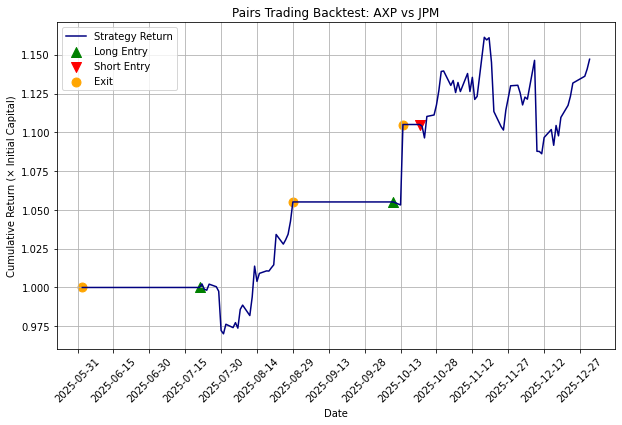

{'total_return': 0.14711982595970619,
 'annualized_return': 0.2632695871984425,
 'sharpe': 1.427934959603688}

In [38]:
trade_plot(df_price,"AXP","JPM")

In [40]:
stocks = df_price.index

results = []
indexes = []
chosen = []

#chosen
for pair in pairs4:
    stockA=pair[0]
    stockB=pair[1]
    chosen.append(str(stockA)+" & "+str(stockB))

# Build index labels
for i in range(len(stocks)):
    for j in range(i+1, len(stocks)):
        indexes.append(str(stocks[i]) + " & " + str(stocks[j]))

# Run backtests
for i in range(len(stocks)):
    for j in range(i+1, len(stocks)):
        result = trade(df_price, stocks[i], stocks[j])
        results.append(result)

df_result = pd.DataFrame(results, index=indexes)
df_result["Chosen"] = df_result.index.isin(chosen)

In [67]:
df_result.sort_values(by="total_return")[:20]

,total_return,annualized_return,sharpe,Chosen
HD & NKE,-0.205781,-0.324496,-1.212918,False
JPM & NKE,-0.142243,-0.229914,-0.646125,False
AXP & NKE,-0.134767,-0.218451,-0.709186,False
AAPL & NKE,-0.094490,-0.155495,-0.415633,False
GS & NKE,-0.073264,-0.121512,-0.283638,False
GS & NVDA,-0.069948,-0.116152,-0.687916,False
BA & MRK,-0.061205,-0.101958,-0.425825,False
CAT & NVDA,-0.045784,-0.076697,-0.289801,False
JNJ & NKE,-0.013752,-0.023303,-0.003724,False
MRK & NKE,-0.009870,-0.016748,-0.028483,False


In [49]:
df_result[df_result['Chosen']==True][['total_return','sharpe']].mean()

total_return    0.166962
sharpe          1.349455
dtype: float64

In [50]:
df_result[df_result['Chosen']==False][['total_return','sharpe']].mean()

total_return    0.249801
sharpe          1.557443
dtype: float64

In [72]:
df_result[df_result['Chosen']==True]

,total_return,annualized_return,sharpe,Chosen
AXP & JPM,0.147120,0.263270,1.427935,True
HD & SHW,0.172498,0.311226,1.709699,True
HON & IBM,0.132065,0.235171,1.155990,True
HON & KO,0.059628,0.103643,0.391241,True
HON & MCD,0.175042,0.316073,1.415433,True
HON & PG,0.216613,0.396334,1.631046,True
HON & V,0.297306,0.557677,2.248316,True
HON & VZ,0.186762,0.338502,1.272807,True
HON & WMT,0.208437,0.380393,1.466568,True
JNJ & WMT,0.144304,0.257994,1.014514,True
